# Import Library

In [1]:
from pynq import Overlay, allocate
import threading
import time
import mmap, struct, time
import json, os
import numpy as np
import math
import matplotlib.pyplot as plt

# Import Files

In [2]:
DW = 24              # Data width (Q9.14 fixed-point)
NUM_BRAMS = 16       # Number of BRAM banks
DIMENSION = 16       # Systolic array dimension

# AXI packet header magic/type values
MAGIC_WRITE  = 0x00C0DE
TYPE_WRITE   = 0x000001
MAGIC_NOTIFY = 0xC0DE
TYPE_WEIGHT_REQ = 0x0003
MAGIC_DATA   = 0xDA7A
TYPE_DATA_DUMP  = 0x0002

In [3]:
# === DECODER LOADING ===
DECODER_MODEL_PATH = os.path.abspath("decoder_model")
DECODER_DATA_PATH = os.path.abspath("decoder_data")
os.makedirs(DECODER_MODEL_PATH, exist_ok=True)
os.makedirs(DECODER_DATA_PATH, exist_ok=True)

# ----- File Definition -----
DECODER_WEIGHT_MEM_FILE = os.path.join(DECODER_MODEL_PATH, "G_d5_Q9.14_decoder_weight.mem")
DECODER_BIAS_MEM_FILE   = os.path.join(DECODER_MODEL_PATH, "G_d5_Q9.14_decoder_bias.mem")
DECODER_IFMAP_L0_FILE   = os.path.join(DECODER_DATA_PATH, "d1_in.mem")
DECODER_IFMAP_L1_FILE   = os.path.join(DECODER_DATA_PATH, "d2_in.mem")
DECODER_IFMAP_L2_FILE   = os.path.join(DECODER_DATA_PATH, "d3_in.mem")
DECODER_IFMAP_L3_FILE   = os.path.join(DECODER_DATA_PATH, "d4_in.mem")

DECODER_L0_RESULT   = os.path.join(DECODER_DATA_PATH, "d1_out.mem")
DECODER_L1_RESULT   = os.path.join(DECODER_DATA_PATH, "d2_out.mem")
DECODER_L2_RESULT   = os.path.join(DECODER_DATA_PATH, "d3_out.mem")
DECODER_L3_RESULT   = os.path.join(DECODER_DATA_PATH, "d4_out.mem")

# ----- Offsets -----
DECODER_WEIGHT_OFFSET_L0 = 0
DECODER_WEIGHT_OFFSET_L1 = 131072
DECODER_WEIGHT_OFFSET_L2 = 196608
DECODER_WEIGHT_OFFSET_L3 = 212992

DECODER_BIAS_OFFSET_L0 = 0
DECODER_BIAS_OFFSET_L1 = 8192
DECODER_BIAS_OFFSET_L2 = 16384
DECODER_BIAS_OFFSET_L3 = 24576

In [4]:
# CONV LOADING 
CONV_MODEL_PATH = os.path.abspath("conv_model")
CONV_DATA_PATH = os.path.abspath("conv_data_13223051")
os.makedirs(CONV_MODEL_PATH, exist_ok=True)
os.makedirs(CONV_DATA_PATH, exist_ok=True)

# WEIGHT
CONV_E1_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e1_weight.txt")
CONV_E2_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e2_weight.txt")
CONV_E3_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e3_weight.txt")
CONV_E4_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "e4_weight.txt")

CONV_B00_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_0_weight.txt")
CONV_B01_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_1_weight.txt")
CONV_B10_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_0_weight.txt")
CONV_B11_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_1_weight.txt")
CONV_B20_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_0_weight.txt")
CONV_B21_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_1_weight.txt")
CONV_B30_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_0_weight.txt")
CONV_B31_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_1_weight.txt")

CONV_OUT_WEIGHT_FILE = os.path.join(CONV_MODEL_PATH, "out_weight.txt")

CONV_WEIGHT_FILES = {
    "E1": CONV_E1_WEIGHT_FILE,
    "E2": CONV_E2_WEIGHT_FILE,
    "E3": CONV_E3_WEIGHT_FILE,
    "E4": CONV_E4_WEIGHT_FILE,

    "B00": CONV_B00_WEIGHT_FILE,
    "B01": CONV_B01_WEIGHT_FILE,
    "B10": CONV_B10_WEIGHT_FILE,
    "B11": CONV_B11_WEIGHT_FILE,
    "B20": CONV_B20_WEIGHT_FILE,
    "B21": CONV_B21_WEIGHT_FILE,
    "B30": CONV_B30_WEIGHT_FILE,
    "B31": CONV_B31_WEIGHT_FILE,

    "OUT": CONV_OUT_WEIGHT_FILE,
}

# BIAS
CONV_E1_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e1_bias.txt")
CONV_E2_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e2_bias.txt")
CONV_E3_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e3_bias.txt")
CONV_E4_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "e4_bias.txt")

CONV_B00_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_0_bias.txt")
CONV_B01_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_0_1_bias.txt")
CONV_B10_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_0_bias.txt")
CONV_B11_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_1_1_bias.txt")
CONV_B20_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_0_bias.txt")
CONV_B21_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_2_1_bias.txt")
CONV_B30_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_0_bias.txt")
CONV_B31_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "bottleneck_3_1_bias.txt")

CONV_OUT_BIAS_FILE = os.path.join(CONV_MODEL_PATH, "out_bias.txt")

CONV_BIAS_FILES = {
    "E1": CONV_E1_BIAS_FILE,
    "E2": CONV_E2_BIAS_FILE,
    "E3": CONV_E3_BIAS_FILE,
    "E4": CONV_E4_BIAS_FILE,

    "B00": CONV_B00_BIAS_FILE,
    "B01": CONV_B01_BIAS_FILE,
    "B10": CONV_B10_BIAS_FILE,
    "B11": CONV_B11_BIAS_FILE,
    "B20": CONV_B20_BIAS_FILE,
    "B21": CONV_B21_BIAS_FILE,
    "B30": CONV_B30_BIAS_FILE,
    "B31": CONV_B31_BIAS_FILE,

    "OUT": CONV_OUT_BIAS_FILE,
}

# IFMAP
CONV_IFMAP_E1_FILE   = os.path.join(CONV_DATA_PATH, "input.txt")
CONV_IFMAP_E2_FILE   = os.path.join(CONV_DATA_PATH, "e1.txt")
CONV_IFMAP_E3_FILE   = os.path.join(CONV_DATA_PATH, "e2.txt")
CONV_IFMAP_E4_FILE   = os.path.join(CONV_DATA_PATH, "e3.txt")

CONV_IFMAP_B00_FILE   = os.path.join(CONV_DATA_PATH, "b0_0_in.txt")
CONV_IFMAP_B01_FILE   = os.path.join(CONV_DATA_PATH, "b0_1_in.txt")
CONV_IFMAP_B10_FILE   = os.path.join(CONV_DATA_PATH, "b1_0_in.txt")
CONV_IFMAP_B11_FILE   = os.path.join(CONV_DATA_PATH, "b1_1_in.txt")
CONV_IFMAP_B20_FILE   = os.path.join(CONV_DATA_PATH, "b2_0_in.txt")
CONV_IFMAP_B21_FILE   = os.path.join(CONV_DATA_PATH, "b2_1_in.txt")
CONV_IFMAP_B30_FILE   = os.path.join(CONV_DATA_PATH, "b3_0_in.txt")
CONV_IFMAP_B31_FILE   = os.path.join(CONV_DATA_PATH, "b3_1_in.txt")

CONV_IFMAP_OUT_FILE   = os.path.join(CONV_DATA_PATH, "d4_out.txt")

CONV_IFMAP_FILES = {
    "E1": CONV_IFMAP_E1_FILE,
    "E2": CONV_IFMAP_E2_FILE,
    "E3": CONV_IFMAP_E3_FILE,
    "E4": CONV_IFMAP_E4_FILE,

    "B00": CONV_IFMAP_B00_FILE,
    "B01": CONV_IFMAP_B01_FILE,
    "B10": CONV_IFMAP_B10_FILE,
    "B11": CONV_IFMAP_B11_FILE,
    "B20": CONV_IFMAP_B20_FILE,
    "B21": CONV_IFMAP_B21_FILE,
    "B30": CONV_IFMAP_B30_FILE,
    "B31": CONV_IFMAP_B31_FILE,

    "OUT": CONV_IFMAP_OUT_FILE,
}

# RESULTS
CONV_E1_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e1.txt")
CONV_E2_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e2.txt")
CONV_E3_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e3.txt")
CONV_E4_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "e4.txt")

CONV_B00_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b0_0_out.txt")
CONV_B01_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b0_1_out.txt")
CONV_B10_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b1_0_out.txt")
CONV_B11_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b1_1_out.txt")
CONV_B20_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b2_0_out.txt")
CONV_B21_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b2_1_out.txt")
CONV_B30_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b3_0_out.txt")
CONV_B31_RESULT_FILE = os.path.join(CONV_DATA_PATH, "b3_1_out.txt")

CONV_OUT_RESULT_FILE   = os.path.join(CONV_DATA_PATH, "out.txt")

CONV_RESULT_FILES = {
    "E1": CONV_E1_RESULT_FILE,
    "E2": CONV_E2_RESULT_FILE,
    "E3": CONV_E3_RESULT_FILE,
    "E4": CONV_E4_RESULT_FILE,

    "B00": CONV_B00_RESULT_FILE,
    "B01": CONV_B01_RESULT_FILE,
    "B10": CONV_B10_RESULT_FILE,
    "B11": CONV_B11_RESULT_FILE,
    "B20": CONV_B20_RESULT_FILE,
    "B21": CONV_B21_RESULT_FILE,
    "B30": CONV_B30_RESULT_FILE,
    "B31": CONV_B31_RESULT_FILE,

    "OUT": CONV_OUT_RESULT_FILE,
}

In [5]:
DECONV_REF_DATA_PATH = os.path.abspath("deconv_data_13223051")

DECONV_REF_RESULT_D1_FILE   = os.path.join(DECONV_REF_DATA_PATH, "d1_out.mem")
DECONV_REF_RESULT_D2_FILE   = os.path.join(DECONV_REF_DATA_PATH, "d2_out.mem")
DECONV_REF_RESULT_D3_FILE   = os.path.join(DECONV_REF_DATA_PATH, "d3_out.mem")
DECONV_REF_RESULT_D4_FILE   = os.path.join(DECONV_REF_DATA_PATH, "d4_out.mem")

DECONV_REF_RESULT_FILES = {
    "D1": DECONV_REF_RESULT_D1_FILE,
    "D2": DECONV_REF_RESULT_D2_FILE,
    "D3": DECONV_REF_RESULT_D3_FILE,
    "D4": DECONV_REF_RESULT_D4_FILE
}

In [6]:
GENERATOR_DATA_PATH = os.path.abspath("generator_data")
os.makedirs(GENERATOR_DATA_PATH, exist_ok=True)

seed_arr = [1234, 420, 67, 69, 13523100, 13223051, 13223075, 42, 21, 20]
generator_data = {}

for seed in seed_arr:
    SEED_PATH = os.path.join(GENERATOR_DATA_PATH, f"{seed}")
    os.makedirs(SEED_PATH, exist_ok=True)
    generator_data[f"{seed}_input_file"] = os.path.join(SEED_PATH, "input.txt")
    generator_data[f"{seed}_output_file"] = os.path.join(SEED_PATH, "out.txt")

# Loading and Ensuring Data is Correct

## Decoder

In [7]:
def load_mem_file(filepath):
    """Load Verilog $readmemh .mem file → numpy uint32 array."""
    values = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.split('//')[0].strip()
            if not line or line.startswith('@'):
                continue
            values.append(int(line, 16))
    return np.array(values, dtype=np.uint32)

In [8]:
print("Loading weight...", end=' ', flush=True)
decoder_weight_data = load_mem_file(DECODER_WEIGHT_MEM_FILE)
print(f"{len(decoder_weight_data)} words")

print("Loading bias...", end=' ', flush=True)
decoder_bias_data = load_mem_file(DECODER_BIAS_MEM_FILE)
print(f"{len(decoder_bias_data)} words")

print("Loading ifmap L0...", end=' ', flush=True)
decoder_ifmap_l0 = load_mem_file(DECODER_IFMAP_L0_FILE)
print(f"{len(decoder_ifmap_l0)} words")

print("Loading ifmap L1...", end=' ', flush=True)
decoder_ifmap_l1 = load_mem_file(DECODER_IFMAP_L1_FILE)
print(f"{len(decoder_ifmap_l1)} words")

print("Loading ifmap L2...", end=' ', flush=True)
decoder_ifmap_l2 = load_mem_file(DECODER_IFMAP_L2_FILE)
print(f"{len(decoder_ifmap_l2)} words")

print("Loading ifmap L3...", end=' ', flush=True)
decoder_ifmap_l3 = load_mem_file(DECODER_IFMAP_L3_FILE)
print(f"{len(decoder_ifmap_l3)} words")

Loading weight... 217088 words
Loading bias... 32768 words
Loading ifmap L0... 8192 words
Loading ifmap L1... 16384 words
Loading ifmap L2... 16384 words
Loading ifmap L3... 16384 words


In [9]:
def load_mem_file_2d(filepath, channels, time_len, dtype=np.uint32):
    values = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.split('//')[0].strip()
            if not line or line.startswith('@'):
                continue
            values.append(int(line, 16))

    arr = np.array(values, dtype=dtype)

    expected_size = channels * time_len
    if arr.size != expected_size:
        raise ValueError(
            f"Size mismatch in {filepath}: "
            f"expected {expected_size}, got {arr.size}"
        )

    arr = arr.reshape((time_len, channels))
    arr = arr.T

    return arr

In [10]:
ch_pos_per_layer = [
    (128, 64),
    (64, 128),
    (32, 256),
    (16, 512)
]

# ---- Load IFMAPS ----

print("Loading IFMAP L0 2D...", flush=True)
decoder_ifmap0_2d = load_mem_file_2d(DECODER_IFMAP_L0_FILE, 256, 32)
print("Shape:", decoder_ifmap0_2d.shape)

print("Loading IFMAP L1 2D...", flush=True)
decoder_ifmap1_2d = load_mem_file_2d(DECODER_IFMAP_L1_FILE, 256, 64)  # doubled channel
print("Shape:", decoder_ifmap1_2d.shape)

print("Loading IFMAP L2 2D...", flush=True)
decoder_ifmap2_2d = load_mem_file_2d(DECODER_IFMAP_L2_FILE, 128, 128)   # doubled channel
print("Shape:", decoder_ifmap2_2d.shape)

print("Loading IFMAP L3 2D...", flush=True)
decoder_ifmap3_2d = load_mem_file_2d(DECODER_IFMAP_L3_FILE, 64, 256)   # doubled channel
print("Shape:", decoder_ifmap3_2d.shape)


# ---- Load RESULTS ----

print("Loading RESULT L0 2D...", flush=True)
decoder_result0_2d = load_mem_file_2d(DECODER_L0_RESULT, 128, 64)
print("Shape:", decoder_result0_2d.shape)

print("Loading RESULT L1 2D...", flush=True)
decoder_result1_2d = load_mem_file_2d(DECODER_L1_RESULT, 64, 128)
print("Shape:", decoder_result1_2d.shape)

print("Loading RESULT L2 2D...", flush=True)
decoder_result2_2d = load_mem_file_2d(DECODER_L2_RESULT, 32, 256)
print("Shape:", decoder_result2_2d.shape)

print("Loading RESULT L3 2D...", flush=True)
decoder_result3_2d = load_mem_file_2d(DECODER_L3_RESULT, 16, 512)
print("Shape:", decoder_result3_2d.shape)

Loading IFMAP L0 2D...
Shape: (256, 32)
Loading IFMAP L1 2D...
Shape: (256, 64)
Loading IFMAP L2 2D...
Shape: (128, 128)
Loading IFMAP L3 2D...
Shape: (64, 256)
Loading RESULT L0 2D...
Shape: (128, 64)
Loading RESULT L1 2D...
Shape: (64, 128)
Loading RESULT L2 2D...
Shape: (32, 256)
Loading RESULT L3 2D...
Shape: (16, 512)


In [11]:
DECODER_LAYER_CFG = {
    0: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L0,
        bias_offset=DECODER_BIAS_OFFSET_L0,
        header_w_weight=1024,
        header_w_ifmap=512,
        header_w_bias=512,
        ich=256,
        pos_ifmap=32,
        pos_groups_ifmap=2,
        bias_pages=8,
        bias_pos=64,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=256,
        weight_oc_stride=1024,
        batches=8
    ),
    1: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L1,
        bias_offset=DECODER_BIAS_OFFSET_L1,
        header_w_weight=1024,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=256,
        pos_ifmap=64,
        pos_groups_ifmap=4,
        bias_pages=4,
        bias_pos=128,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=256,
        weight_oc_stride=1024,
        batches=4
    ),
    2: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L2,
        bias_offset=DECODER_BIAS_OFFSET_L2,
        header_w_weight=1024,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=128,
        pos_ifmap=128,
        pos_groups_ifmap=8,
        bias_pages=2,
        bias_pos=256,
        weight_tiles=8,
        weight_oc_per_tile=4,
        weight_k_stride=128,
        weight_oc_stride=512,
        batches=1
    ),
    3: dict(
        weight_offset=DECODER_WEIGHT_OFFSET_L3,
        bias_offset=DECODER_BIAS_OFFSET_L3,
        header_w_weight=256,
        header_w_ifmap=1024,
        header_w_bias=512,
        ich=64,
        pos_ifmap=256,
        pos_groups_ifmap=16,
        bias_pages=1,
        bias_pos=512,
        weight_tiles=4,
        weight_oc_per_tile=4,
        weight_k_stride=64,
        weight_oc_stride=256,
        batches=1
    ),
}

In [12]:
def _header(num_words_per_bram): 
    """6-word packet header.""" 
    return [0x00C0DE, 0x000001, 0, 15, 0, int(num_words_per_bram)] 

def _pack(arr): 
    """Convert Python list → numpy uint32, mask to 24-bit.""" 
    return np.array(arr, dtype=np.uint32) & 0xFFFFFF

def decoder_build_weight(layer_id, weight, batch_id=0):
    cfg = DECODER_LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_weight"])

    for bram_id in range(16):
        k_pos      = bram_id & 0x3
        oc_in_tile = (bram_id >> 2) & 0x3

        for tile in range(cfg["weight_tiles"]):
            oc_abs = batch_id * 16 + tile * 4 + oc_in_tile

            for ich in range(cfg["ich"]):
                addr = (
                    cfg["weight_offset"]
                    + oc_abs * cfg["weight_oc_stride"]
                    + k_pos * cfg["weight_k_stride"]
                    + ich
                )
                buf.append(int(weight[addr]) & 0xFFFFFF)

    return _pack(buf)

def decoder_build_ifmap(layer_id, ifmap):
    cfg = DECODER_LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_ifmap"])

    for bram_id in range(16):
        for pos_group in range(cfg["pos_groups_ifmap"]):
            position = bram_id + pos_group * 16

            for ch in range(cfg["ich"]):
                idx = position * cfg["ich"] + ch
                buf.append(int(ifmap[idx]) & 0xFFFFFF)

    return _pack(buf)

def decoder_build_bias(layer_id, bias):
    cfg = DECODER_LAYER_CFG[layer_id]

    buf = _header(cfg["header_w_bias"])

    for bram_id in range(16):
        for page in range(cfg["bias_pages"]):
            ch = page * 16 + bram_id

            for pos in range(cfg["bias_pos"]):
                idx = cfg["bias_offset"] + ch * cfg["bias_pos"] + pos
                buf.append(int(bias[idx]) & 0xFFFFFF)

    return _pack(buf)

def decoder_build_packet(data_array, layer_id):
    """
    Build packet for hardware.
    Format:
    [ layer_id | length | payload... ]
    """
    length = len(data_array)

    header = np.array([
        np.uint32(layer_id),
        np.uint32(length)
    ], dtype=np.uint32)

    packet = np.concatenate((header, data_array))
    return packet

In [13]:
t0 = time.time()
print("Building packets...")

DECODER_PACKETS = {}

for layer_id in range(4):

    cfg = DECODER_LAYER_CFG[layer_id]
    print(f"\nLayer {layer_id}...")

    # ---- WEIGHT ----
    if cfg["batches"] > 1:
        print(f"  Weights ({cfg['batches']} batches)...", end=' ', flush=True)
        DECODER_PACKETS[f"w_l{layer_id}"] = [
            decoder_build_weight(layer_id, decoder_weight_data, b)
            for b in range(cfg["batches"])
        ]
        total = sum(len(p) for p in DECODER_PACKETS[f"w_l{layer_id}"])
        print(f"{total:,} words total")
    else:
        print("  Weight...", end=' ', flush=True)
        DECODER_PACKETS[f"w_l{layer_id}"] = decoder_build_weight(layer_id, decoder_weight_data)
        print(f"{len(DECODER_PACKETS[f'w_l{layer_id}']):,} words")

    # ---- IFMAP ----
    print("  IFMAP...", end=' ', flush=True)
    DECODER_PACKETS[f"i_l{layer_id}"] = decoder_build_ifmap(layer_id, globals()[f"decoder_ifmap_l{layer_id}"])
    print(f"{len(DECODER_PACKETS[f'i_l{layer_id}']):,} words")

    # ---- BIAS ----
    print("  Bias...", end=' ', flush=True)
    DECODER_PACKETS[f"b_l{layer_id}"] = decoder_build_bias(layer_id, decoder_bias_data)
    print(f"{len(DECODER_PACKETS[f'b_l{layer_id}']):,} words")

print(f"\nBuild finished in {time.time()-t0:.1f} seconds")

Building packets...

Layer 0...
  Weights (8 batches)... 131,120 words total
  IFMAP... 8,198 words
  Bias... 8,198 words

Layer 1...
  Weights (4 batches)... 65,560 words total
  IFMAP... 16,390 words
  Bias... 8,198 words

Layer 2...
  Weight... 16,390 words
  IFMAP... 16,390 words
  Bias... 8,198 words

Layer 3...
  Weight... 4,102 words
  IFMAP... 16,390 words
  Bias... 8,198 words

Build finished in 2.8 seconds


## Deconv Reference

In [14]:
ch_pos_per_layer = [
    (128, 64),
    (64, 128),
    (32, 256),
    (16, 512)
]

DECONV_REFERENCE_RESULT = {}

for idx, (layer_name, filepath) in enumerate(DECONV_REF_RESULT_FILES.items()):
    channels, time_len = ch_pos_per_layer[idx]

    DECONV_REFERENCE_RESULT[layer_name] = load_mem_file_2d(
        filepath,
        channels,
        time_len
    )

## Convolution

In [15]:
def load_conv_bias_txt(filename, shape, dtype=np.int32):
    values = []

    with open(filename, "r") as f:
        for line in f:
            hex_str = line.strip()
            if not hex_str:
                continue

            if dtype == np.int16:
                val = np.int16(int(hex_str, 16))
            elif dtype == np.int32:
                bits = np.uint32(int(hex_str, 16))
                val = bits.view(np.int32)
            elif dtype == np.float32:
                bits = np.uint32(int(hex_str, 16))
                val = np.frombuffer(bits.tobytes(), dtype=np.float32)[0]
            else:
                raise ValueError("Unsupported dtype")

            values.append(val)

    arr = np.array(values, dtype=dtype)
    return arr.reshape(shape)

def load_conv_weight_txt(filename, shape, dtype=np.int32):
    x_dim, y_dim, z_dim = shape
    data = np.zeros(shape, dtype=dtype)

    with open(filename, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    expected_lines = x_dim * z_dim
    if len(lines) != expected_lines:
        raise ValueError(
            f"Expected {expected_lines} lines, got {len(lines)}"
        )

    line_idx = 0

    for x in range(x_dim):
        for z in range(z_dim):
            tokens = lines[line_idx].split()

            if len(tokens) != y_dim:
                raise ValueError(
                    f"Expected {y_dim} values per line, got {len(tokens)}"
                )

            for y in range(y_dim):
                hex_str = tokens[y]

                if dtype == np.int16:
                    bits = np.uint16(int(hex_str, 16))
                    val = bits.view(np.int16)
                elif dtype == np.int32:
                    bits = np.uint32(int(hex_str, 16))
                    val = bits.view(np.int32)
                elif dtype == np.float32:
                    bits = np.uint32(int(hex_str, 16))
                    val = np.frombuffer(bits.tobytes(), dtype=np.float32)[0]
                else:
                    raise ValueError("Unsupported dtype")

                data[x, y, z] = val

            line_idx += 1

    return data

def load_conv_ifmap_hex(path, dtype=np.int32):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    rows = len(lines)
    if rows == 0:
        raise ValueError("Empty file")

    cols = len(lines[0].split())

    data = np.zeros((cols, rows), dtype=np.int32)

    for r, line in enumerate(lines):
        tokens = line.split()

        if len(tokens) != cols:
            raise ValueError(
                f"Inconsistent column count at row {r}"
            )

        for c in range(cols):
            bits = np.uint32(int(tokens[c], 16))
            data[c, r] = bits.view(np.int32)

    if cols == 1:
        return data.reshape(-1)

    return data

In [16]:
# === WEIGHTS ===
CONV_WEIGHT_SHAPES = {
    # ENCODER
    "E1": (32, 1, 16),
    "E2": (64, 32, 16),
    "E3": (128, 64, 16),
    "E4": (256, 128, 16),

    # BOTTLENECK
    "B00": (256, 256, 7),
    "B01": (256, 256, 7),
    "B10": (256, 256, 7),
    "B11": (256, 256, 7),
    "B20": (256, 256, 7),
    "B21": (256, 256, 7),
    "B30": (256, 256, 7),
    "B31": (256, 256, 7),

    # OUTPUT
    "OUT": (1, 16, 7),
}


if 'CONV_WEIGHTS' not in globals() or not CONV_WEIGHTS:
    print("Loading convolution weights...")
    CONV_WEIGHTS = {}

    for layer_name, filepath in CONV_WEIGHT_FILES.items():
        shape = CONV_WEIGHT_SHAPES[layer_name]
        CONV_WEIGHTS[layer_name] = load_conv_weight_txt(filepath, shape)

    print("All convolution weights loaded.")
else:
    print("Using already loaded convolution weights.")

Loading convolution weights...
All convolution weights loaded.


In [17]:
# === BIAS ===
CONV_BIAS_SHAPES = {
    "E1": (32,),
    "E2": (64,),
    "E3": (128,),
    "E4": (256,),

    "B00": (256,),
    "B01": (256,),
    "B10": (256,),
    "B11": (256,),
    "B20": (256,),
    "B21": (256,),
    "B30": (256,),
    "B31": (256,),

    "OUT": (1,),
}

if 'CONV_BIASES' not in globals() or not CONV_BIASES:
    CONV_BIASES = {}

    for layer_name, filepath in CONV_BIAS_FILES.items():
        shape = CONV_BIAS_SHAPES[layer_name]
        CONV_BIASES[layer_name] = load_conv_bias_txt(filepath, shape)

    print("All convolution biases loaded.")
else:
    print("Using already loaded convolution bias.")

All convolution biases loaded.


In [18]:
# === IFMAP ===
if 'CONV_IFMAPS' not in globals() or not CONV_IFMAPS:
    CONV_IFMAPS = {}

    for layer_name, filepath in CONV_IFMAP_FILES.items():
        CONV_IFMAPS[layer_name] = load_conv_ifmap_hex(filepath)

    print("All convolution IFMAPs loaded.")
else:
    print("Using already loaded convolution ifmaps.")

All convolution IFMAPs loaded.


In [19]:
# === RESULTS ===
if 'CONV_RESULTS' not in globals() or not CONV_RESULTS:
    CONV_RESULTS = {}

    for layer_name, filepath in CONV_RESULT_FILES.items():
        CONV_RESULTS[layer_name] = load_conv_ifmap_hex(filepath)

    print("All convolution reference results loaded.")
else:
    print("Using already loaded convolution ifmaps.")

All convolution reference results loaded.


In [20]:
SEEDS = [
    "1234",
    "420",
    "67",
    "69",
    "13523100",
    "13223051",
    "13223075",
    "42",
    "21",
    "20",
]

GENERATOR_IN = {}
GENERATOR_OUT = {}

for seed in SEEDS:
    GENERATOR_IN[seed]  = load_conv_ifmap_hex(generator_data[f"{seed}_input_file"])
    GENERATOR_OUT[seed] = load_conv_ifmap_hex(generator_data[f"{seed}_output_file"])

print("All generator inputs and outputs loaded.")

All generator inputs and outputs loaded.


In [21]:
def graph_ifmap(data, title="IFMAP Visualization", mode="auto"):
    """
    Graph IFMAP data returned from load_conv_ifmap_hex().

    Parameters
    ----------
    data : np.ndarray
        Output from load_conv_ifmap_hex
    title : str
        Plot title
    mode : str
        "auto"      -> choose automatically
        "flatten"   -> flatten and plot as single signal
        "channels"  -> overlay each channel
        "heatmap"   -> 2D heatmap
    """

    arr = np.array(data)

    if mode == "auto":
        mode = "flatten" if arr.ndim == 1 else "heatmap"

    plt.figure()

    if mode == "flatten":
        flat = arr.flatten()
        plt.plot(flat)
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.title(title + " (Flattened)")

    elif mode == "channels":
        if arr.ndim == 1:
            plt.plot(arr)
        else:
            for ch in range(arr.shape[0]):
                plt.plot(arr[ch], alpha=0.5)
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.title(title + " (Channels)")

    elif mode == "heatmap":
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        plt.imshow(arr, aspect="auto")
        plt.colorbar()
        plt.xlabel("Time")
        plt.ylabel("Channel")
        plt.title(title + " (Heatmap)")

    else:
        raise ValueError("mode must be 'auto', 'flatten', 'channels', or 'heatmap'")

    plt.tight_layout()
    plt.show()

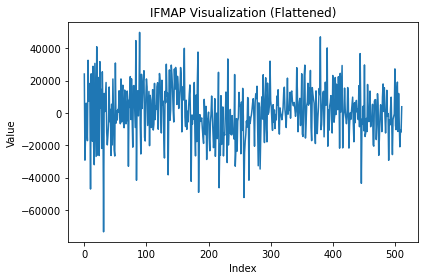

In [22]:
graph_ifmap(CONV_IFMAPS["E1"], mode="flatten")

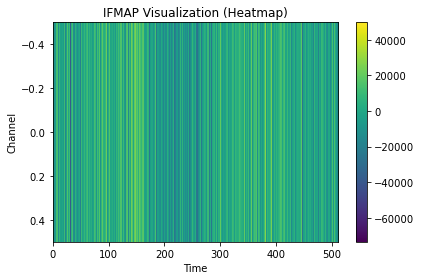

In [23]:
graph_ifmap(CONV_IFMAPS["E1"], mode="heatmap")

# Loading Hardware

In [24]:
# Generator
generator_imp_path = os.path.abspath("generator_bitstream")
os.makedirs(generator_imp_path, exist_ok=True)

generator_overlay = Overlay(os.path.join(generator_imp_path, "design_integration.bit"))

In [25]:
# Generator
generator_dma_weight = generator_overlay.axi_dma_0
generator_dma_bias = generator_overlay.axi_dma_1
generator_dma_ifmap = generator_overlay.axi_dma_2

In [26]:
print("IFMAP0 Has sendchannel:", generator_dma_ifmap.sendchannel is not None)
print("IFMAP0 Has recvchannel:", generator_dma_ifmap.recvchannel is not None)

print("BIAS1 Has sendchannel:", generator_dma_bias.sendchannel is not None)
print("BIAS1 Has recvchannel:", generator_dma_bias.recvchannel is not None)

print("WEIGHT2 Has sendchannel:", generator_dma_weight.sendchannel is not None)
print("WEIGHT2 Has recvchannel:", generator_dma_weight.recvchannel is not None)

IFMAP0 Has sendchannel: True
IFMAP0 Has recvchannel: True
BIAS1 Has sendchannel: True
BIAS1 Has recvchannel: False
WEIGHT2 Has sendchannel: True
WEIGHT2 Has recvchannel: True


# Utility Data Load to FPGA

In [27]:
LAYER_CONFIG = [
    # (input_channels, filters, temporal_len, kernel_size, stride, padding)
    # --- Encoder (layers 0-3) ---
    (1,   32,  512, 16, 2, 7),   # Layer 0: e1
    (32,  64,  256, 16, 2, 7),   # Layer 1: e2
    (64,  128, 128, 16, 2, 7),   # Layer 2: e3
    (128, 256, 64,  16, 2, 7),   # Layer 3: e4
    # --- Bottleneck (layers 4-11) ---
    (256, 256, 32, 7, 1, 3),     # Layer 4:  bn_0_0
    (256, 256, 32, 7, 1, 3),     # Layer 5:  bn_0_1
    (256, 256, 32, 7, 1, 3),     # Layer 6:  bn_1_0
    (256, 256, 32, 7, 1, 3),     # Layer 7:  bn_1_1
    (256, 256, 32, 7, 1, 3),     # Layer 8:  bn_2_0
    (256, 256, 32, 7, 1, 3),     # Layer 9:  bn_2_1
    (256, 256, 32, 7, 1, 3),     # Layer 10: bn_3_0
    (256, 256, 32, 7, 1, 3),     # Layer 11: bn_3_1
     # --- Output ---
    (16,  1,   512, 7, 1, 3),    
]

# Execution Utility Functions

In [28]:
def build_axi_packet(bram_start, bram_end, addr_start, data_count, payload):
    num_brams = bram_end - bram_start + 1
    total_payload = num_brams * data_count
    
    assert len(payload) == total_payload, \
        f"Payload size mismatch: expected {total_payload}, got {len(payload)}"
    
    # 6-word header
    header = [
        MAGIC_WRITE,         # Word 0: magic
        TYPE_WRITE,          # Word 1: type (write)
        bram_start,          # Word 2: bram_start
        bram_end,            # Word 3: bram_end
        addr_start,          # Word 4: addr_start
        data_count,          # Word 5: data_count (words per BRAM)
    ]
    
    # Combine header + payload (mask to 24-bit, zero-pad to 32-bit)
    packet = np.zeros(6 + total_payload, dtype=np.uint32)
    for i, h in enumerate(header):
        packet[i] = h & 0xFFFFFFFF
    for i, val in enumerate(payload):
        packet[6 + i] = val & 0xFFFFFF  # DW=24 bit mask
    
    return packet

def build_bias_packet(layer_id, bias_array):
    ic, num_filters, temp, kern, stride, pad = LAYER_CONFIG[layer_id]
    o_len = out_len(layer_id)

    num_batches = (num_filters + NUM_BRAMS - 1) // NUM_BRAMS
    words_per_bram = num_batches * o_len

    # Safety check
    assert len(bias_array) == num_filters, \
        f"Bias length mismatch: expected {num_filters}, got {len(bias_array)}"

    payload = []

    # Build payload exactly like original function
    for f in range(NUM_BRAMS):  # 16 BRAMs
        for batch in range(num_batches):
            f_abs = batch * NUM_BRAMS + f
            for t in range(o_len):
                if f_abs < num_filters:
                    payload.append(int(bias_array[f_abs]))
                else:
                    payload.append(0)

    packet = build_axi_packet(
        bram_start=0,
        bram_end=NUM_BRAMS - 1,
        addr_start=0,
        data_count=words_per_bram,
        payload=payload
    )

    print(f"  Bias L{layer_id}: {num_filters} filters x {o_len} steps x "
          f"{num_batches} batches = {len(payload)} words")

    return packet

def build_ifmap_packet(layer_id, ifmap_array):
    """
    Build IFMAP AXI packet from already-loaded IFMAP array.
    Expected input shape:
        (ic, temp_len)  OR
        (temp_len, ic)
    Returns:
        np.ndarray(dtype=np.uint32)
    """

    ic, filt, temp_len, kern, stride, pad = LAYER_CONFIG[layer_id]

    num_brams_used = min(ic, 16)
    slots = (ic + 15) // 16
    words_per_bram = slots * temp_len

    # -------------------------------------------------
    # Normalize input shape to raw_data[t, ch]
    # -------------------------------------------------
    if ic == 1:
        if ifmap_array.ndim == 1:
            if ifmap_array.shape[0] != temp_len:
                raise ValueError(
                    f"Expected length {temp_len}, got {ifmap_array.shape[0]}"
                )
            raw_data = ifmap_array.reshape(temp_len, 1)
        else:
            raw_data = ifmap_array.reshape(temp_len, 1)
    else:
        if ifmap_array.ndim != 2:
            raise ValueError("IFMAP must be 2D for multi-channel layer")

        # Loader format: (channels, timesteps)
        if ifmap_array.shape == (ic, temp_len):
            raw_data = ifmap_array.T
        elif ifmap_array.shape == (temp_len, ic):
            raw_data = ifmap_array
        else:
            raise ValueError(
                f"Unexpected IFMAP shape {ifmap_array.shape}, "
                f"expected ({ic},{temp_len}) or ({temp_len},{ic})"
            )
            
    # -------------------------------------------------
    # Build BRAM payload (IDENTICAL LOGIC AS ORIGINAL)
    # -------------------------------------------------
    payload = []

    for b in range(num_brams_used):
        for s in range(slots):
            ch = b + s * 16
            for t in range(temp_len):
                if ch < ic:
                    payload.append(int(raw_data[t, ch]))
                else:
                    payload.append(0)

    packet = build_axi_packet(
        bram_start=0,
        bram_end=num_brams_used - 1,
        addr_start=0,
        data_count=words_per_bram,
        payload=payload
    )

    print(f"  Ifmap L{layer_id}: {ic}ch x {temp_len}t -> "
          f"{num_brams_used} BRAMs x {words_per_bram} words = {len(payload)} total")

    return packet

def build_weight_packet(layer_id, weight_data,
                                     filter_start, ch_start, ch_count):
    """
    Build weight AXI packet from preloaded CONV_WEIGHTS array.

    weight_data expected shape:
        (filters, channels, kernel)
    """

    ic, num_filters, _, kern, _, _ = LAYER_CONFIG[layer_id]

    # Normalize layout to [f, k, ch]
    if weight_data.shape == (num_filters, ic, kern):
        weight = np.transpose(weight_data, (0, 2, 1))  # -> (f, k, ch)
    elif weight_data.shape == (num_filters, kern, ic):
        weight = weight_data
    else:
        raise ValueError(
            f"Unexpected weight shape {weight_data.shape}, "
            f"expected ({num_filters},{ic},{kern})"
        )

    num_f = min(DIMENSION, num_filters - filter_start)
    words_per_bram = ch_count * kern

    payload = []

    for f_local in range(num_f):
        f_abs = filter_start + f_local
        for ch_local in range(ch_count):
            ch_abs = ch_start + ch_local
            for k in range(kern):
                if f_abs < num_filters and ch_abs < ic:
                    payload.append(int(weight[f_abs, k, ch_abs]))
                else:
                    payload.append(0)

    packet = build_axi_packet(
        bram_start=0,
        bram_end=num_f - 1,
        addr_start=0,
        data_count=words_per_bram,
        payload=payload
    )

    return packet

In [29]:
def build_initial_weight_packet(layer_id, layer_name):
    weight_data = CONV_WEIGHTS[layer_name]

    ic = LAYER_CONFIG[layer_id][0]
    ch_count = min(64, ic)

    print(f"  Weight L{layer_id}: initial batch "
          f"(f=0..{DIMENSION-1}, ch=0..{ch_count-1})")

    return build_weight_packet(
        layer_id,
        weight_data,
        filter_start=0,
        ch_start=0,
        ch_count=ch_count
    )

def build_reload_weight_packet(layer_id, layer_name, req_count):
    weight_data = CONV_WEIGHTS[layer_name]

    ic, num_filters, _, _, _, _ = LAYER_CONFIG[layer_id]

    ch_batches = max(1, (ic + 63) // 64)

    batch_idx = req_count + 1
    filter_batch = batch_idx // ch_batches
    ch_block = batch_idx % ch_batches

    filter_start = filter_batch * DIMENSION
    ch_start = ch_block * 64
    ch_count = min(64, ic - ch_start)

#     print(f"  Weight L{layer_id}: reload #{req_count} "
#           f"(f={filter_start}..{filter_start+DIMENSION-1}, "
#           f"ch={ch_start}..{ch_start+ch_count-1})")

    return build_weight_packet(
        layer_id,
        weight_data,
        filter_start,
        ch_start,
        ch_count
    )

In [30]:
def parse_notification_packet(raw_data):
    """
    Check if received packet is a C0DE notification (weight request).
    Returns (is_notification, packet_type, layer_id) tuple.
    """
    if len(raw_data) < 2:
        return False, 0, 0
    magic = raw_data[0] & 0xFFFF
    ptype = raw_data[1] & 0xFFFF
    layer = raw_data[2] & 0xF if len(raw_data) > 2 else 0
    return (magic == MAGIC_NOTIFY), ptype, layer


def reconstruct_conv_output(m0_payload, m1_payload, layer_id):
    """
    Reconstruct conv layer output from m0 (BRAM 0-7) and m1 (BRAM 8-15) payloads.
    
    Returns: np.array shape [out_len, num_filters] as signed Q9.14 integers.
    """
    num_filters = LAYER_CONFIG[layer_id][1]
    o_len = out_len(layer_id)
    num_batches = (num_filters + NUM_BRAMS - 1) // NUM_BRAMS
    
    output = np.zeros((o_len, num_filters), dtype=np.int32)
    
    for t in range(o_len):
        for f in range(num_filters):
            filter_batch = f // NUM_BRAMS
            local_f = f % NUM_BRAMS
            buf_offset = (local_f % 8) * 512 + filter_batch * o_len + t
            
            if local_f < 8:
                val = m0_payload[buf_offset] if buf_offset < len(m0_payload) else 0
            else:
                val = m1_payload[buf_offset] if buf_offset < len(m1_payload) else 0
            
            output[t, f] = sign_extend_24(val)
    
    return output

# Execution Setup

In [31]:
# ============================================================
# CELL: FULL DMA RECOVERY — Jalankan ini, lalu restart kernel jika perlu
# ============================================================

def hard_start_channel(dma, channel_name):
    if channel_name == 'send':
        cr_offset = 0x00
        sr_offset = 0x04
    else:
        cr_offset = 0x30
        sr_offset = 0x34

    # Reset channel
    dma.write(cr_offset, 0x4)
    timeout = 0
    while (dma.read(cr_offset) & 0x4) and timeout < 10000:
        timeout += 1
    
    # Set RS=1 (Run/Stop bit) langsung ke register
    current_cr = dma.read(cr_offset)
    dma.write(cr_offset, current_cr | 0x1)
    
    sr = dma.read(sr_offset)
    running = (dma.read(cr_offset) & 0x1) == 1
    halted  = (sr & 0x1)
    print(f"  {channel_name}: CR=0x{dma.read(cr_offset):08X} SR=0x{sr:08X} running={running} halted={halted}")

def full_dma_reset(dma, name, has_recv=True):
    print(f"Resetting {name}...")
    hard_start_channel(dma, 'send')
    if has_recv:
        hard_start_channel(dma, 'recv')
    
    # Sync PYNQ internal state — trick: akses _reset langsung
    try:
        dma.sendchannel._flush_before_transfer = True
        dma.sendchannel._first_transfer = True
        if has_recv and dma.recvchannel is not None:
            dma.recvchannel._flush_before_transfer = True
            dma.recvchannel._first_transfer = True
    except Exception as e:
        print(f"  PYNQ state sync warning: {e}")

def reset_dma_channels(*dma_list):
    for dma_obj in dma_list:
        # MM2S reset (offset 0x00, bit 2)
        dma_obj.write(0x00, 0x4)
        for _ in range(1000):
            if not (dma_obj.read(0x00) & 0x4):
                break
        # S2MM reset (offset 0x30, bit 2)
        dma_obj.write(0x30, 0x4)
        for _ in range(1000):
            if not (dma_obj.read(0x30) & 0x4):
                break
        # Clear any pending IRQ flags (W1C) on both channels
        dma_obj.write(0x04, 0x7000)   # MM2S SR
        dma_obj.write(0x34, 0x7000)   # S2MM SR
        # Re-arm both channels so PYNQ's channel objects are in a known state
        try:
            dma_obj.sendchannel.start()
        except:
            pass
        try:
            dma_obj.recvchannel.start()
        except:
            pass
            
def reset_dma_safe(dma, name, has_s2mm=True):
    # MM2S reset
    dma.write(0x00, 0x4)
    for _ in range(100):
        if not (dma.read(0x00) & 0x4): break
        time.sleep(0.001)
    else:
        print(f"  WARNING: {name} MM2S reset did not self-clear")

    # S2MM reset
    if has_s2mm:
        dma.write(0x30, 0x4)
        for _ in range(100):
            if not (dma.read(0x30) & 0x4): break
            time.sleep(0.001)
        else:
            print(f"  WARNING: {name} S2MM reset did not self-clear")

    # Start channels via PYNQ API
    dma.sendchannel.start()
    if has_s2mm:
        dma.recvchannel.start()

    # SR=0 is normal right after reset+start before any transfer.
    # Check MM2S_DMACR (0x00) instead — bit0=RS should be 1 if running.
    mm2s_cr = dma.read(0x00)
    s2mm_cr = dma.read(0x30) if has_s2mm else None
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34) if has_s2mm else None

    print(f"  {name}:")
    print(f"    MM2S CR=0x{mm2s_cr:08X} SR=0x{mm2s_sr:08X}  RS(running)={(mm2s_cr>>0)&1}")
    if has_s2mm:
        print(f"    S2MM CR=0x{s2mm_cr:08X} SR=0x{s2mm_sr:08X}  RS(running)={(s2mm_cr>>0)&1}")

    # OK = RS bit is set (DMA is running), not based on SR value
    ok = bool((mm2s_cr >> 0) & 1)
    if has_s2mm:
        ok = ok and bool((s2mm_cr >> 0) & 1)
    print(f"    → {'OK' if ok else 'FAILED — RS bit not set'}")
    return ok

def full_reset(overlay_obj, dma_map):
    print("Reloading bitstream...")
    overlay_obj.reset()
    print("Overlay reloaded. Re-binding DMAs...")

    dmas = {}
    for attr_name, display_name, has_s2mm in dma_map:
        dma = getattr(overlay_obj, attr_name)
        ok  = reset_dma_safe(dma, display_name, has_s2mm=has_s2mm)
        if not ok:
            raise RuntimeError(f"DMA '{display_name}' failed to initialize — do not proceed")
        dmas[display_name] = dma

    print("Full reset complete — hardware and DMAs are in a clean state.")
    return dmas

def pynq_proper_reset(dma, name, has_recv=True):
    try: dma.sendchannel.stop()
    except: pass
    if has_recv and dma.recvchannel is not None:
        try: dma.recvchannel.stop()
        except: pass
    dma.sendchannel._first_transfer = True
    if has_recv and dma.recvchannel is not None:
        dma.recvchannel._first_transfer = True
    dma.sendchannel.start()
    if has_recv and dma.recvchannel is not None:
        dma.recvchannel.start()
    print(f"{name}: send.running={dma.sendchannel.running}", end="")
    if has_recv and dma.recvchannel:
        print(f" recv.running={dma.recvchannel.running}", end="")
    print()

In [32]:
# Setup
full_dma_reset(generator_dma_weight, "dma_weight", has_recv=True)
full_dma_reset(generator_dma_ifmap,  "dma_ifmap",  has_recv=True)
full_dma_reset(generator_dma_bias,   "dma_bias",   has_recv=False)

print("\n=== VERIFIKASI AKHIR ===")
for name, dma in [("dma_weight", generator_dma_weight), ("dma_ifmap", generator_dma_ifmap), ("dma_bias", generator_dma_bias)]:
    mm2s_cr = dma.read(0x00)
    s2mm_cr = dma.read(0x30)
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34)
    print(f"{name}: MM2S RS={mm2s_cr&1} SR=0x{mm2s_sr:08X} | S2MM RS={s2mm_cr&1} SR=0x{s2mm_sr:08X}")

    if mm2s_sr & 0x70:
        print(f"  ⚠ MM2S ERROR FLAGS: IntErr={(mm2s_sr>>4)&1} SlvErr={(mm2s_sr>>5)&1} DecErr={(mm2s_sr>>6)&1}")
    if s2mm_sr & 0x70:
        print(f"  ⚠ S2MM ERROR FLAGS: IntErr={(s2mm_sr>>4)&1} SlvErr={(s2mm_sr>>5)&1} DecErr={(s2mm_sr>>6)&1}")

pynq_proper_reset(generator_dma_weight, "dma_weight", has_recv=True)
pynq_proper_reset(generator_dma_ifmap,  "dma_ifmap",  has_recv=True)
pynq_proper_reset(generator_dma_bias,   "dma_bias",   has_recv=False)

print("\n=== VERIFIKASI ===")
for name, dma, has_recv in [
    ("dma_weight", generator_dma_weight, True),
    ("dma_ifmap",  generator_dma_ifmap,  True),
    ("dma_bias",   generator_dma_bias,   False)
]:
    mm2s = dma.read(0x00) & 1
    s2mm = dma.read(0x30) & 1
    mm2s_sr = dma.read(0x04)
    s2mm_sr = dma.read(0x34)
    print(f"{name}: MM2S RS={mm2s} | S2MM RS={s2mm} | send.running={dma.sendchannel.running}")
    if has_recv and dma.recvchannel:
        print(f"         recv.running={dma.recvchannel.running}")
    if mm2s_sr & 0x70:
        print(f"  ⚠ MM2S ERR: 0x{mm2s_sr:08X}")
    if s2mm_sr & 0x70:
        print(f"  ⚠ S2MM ERR: 0x{s2mm_sr:08X}")

Resetting dma_weight...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0
  recv: CR=0x00010003 SR=0x00000000 running=True halted=0
Resetting dma_ifmap...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0
  recv: CR=0x00010003 SR=0x00000000 running=True halted=0
Resetting dma_bias...
  send: CR=0x00010003 SR=0x00000000 running=True halted=0

=== VERIFIKASI AKHIR ===
dma_weight: MM2S RS=0 SR=0x00000001 | S2MM RS=1 SR=0x00000000
dma_ifmap: MM2S RS=0 SR=0x00000001 | S2MM RS=1 SR=0x00000000
dma_bias: MM2S RS=1 SR=0x00000000 | S2MM RS=0 SR=0x00000000
dma_weight: send.running=True recv.running=True
dma_ifmap: send.running=True recv.running=True
dma_bias: send.running=True

=== VERIFIKASI ===
dma_weight: MM2S RS=1 | S2MM RS=1 | send.running=True
         recv.running=True
dma_ifmap: MM2S RS=1 | S2MM RS=1 | send.running=True
         recv.running=True
dma_bias: MM2S RS=1 | S2MM RS=0 | send.running=True


In [33]:
DMA_MAP = [
    ("axi_dma_0", "dma_ifmap", True),
    ("axi_dma_1", "dma_bias",  False),
    ("axi_dma_2", "dma_weight",   True),
]

dmas = full_reset(generator_overlay, DMA_MAP)
dma_weight = dmas["dma_weight"]
dma_ifmap  = dmas["dma_ifmap"]
dma_bias   = dmas["dma_bias"]

Reloading bitstream...
Overlay reloaded. Re-binding DMAs...
  dma_ifmap:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    S2MM CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
  dma_bias:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
  dma_weight:
    MM2S CR=0x00010003 SR=0x00000000  RS(running)=1
    S2MM CR=0x00010003 SR=0x00000000  RS(running)=1
    → OK
Full reset complete — hardware and DMAs are in a clean state.


# Execution

In [34]:
def dma_send(dma, packet):
    buf = allocate(shape=(len(packet),), dtype=np.uint32)
    buf[:] = packet
    dma.sendchannel.transfer(buf)
    dma.sendchannel.wait()
    buf.freebuffer()
    
def dma_send_async(dma, packet_np):
    buf = allocate(shape=(len(packet_np),), dtype=np.uint32)
    np.copyto(buf, packet_np)

    dma.sendchannel.transfer(buf)
    
    return buf

def out_len(layer_id):
    """Calculate output temporal length for a conv layer."""
    ic, filt, temp, kern, stride, pad = LAYER_CONFIG[layer_id]
    return (temp + 2 * pad - kern) // stride + 1

In [35]:
def print_layer_output(output, layer_name):
    """
    Pretty-print reconstructed conv output array.
    Expects output shape: [num_channels, num_positions]
    """

    num_ch, num_pos = output.shape

    print("\n=============================================================")
    print(f"{layer_name} OUTPUT: {num_ch} Channels x {num_pos} Positions")
    print("=============================================================")

    group_size = 8
    num_groups = (num_ch + group_size - 1) // group_size

    for grp in range(num_groups):
        grp_start = grp * group_size
        grp_end   = min(grp_start + group_size, num_ch)

        print(f"\n--- Channels {grp_start:3d} - {grp_end-1:3d} ---")

        # Header
        hdr = " Pos |"
        for c in range(grp_start, grp_end):
            hdr += f" Ch{c:3d} |"
        print(hdr)

        print("-----|" + "-------|" * (grp_end - grp_start))

        # Rows
        for pos in range(num_pos):
            row = f" {pos:3d} |"
            for c in range(grp_start, grp_end):
                row += f" {int(output[c, pos]):5d} |"
            print(row)

    print("\n=============================================================\n")

In [36]:
def run_conv_layer(LAYER_ID, LAYER_NAME, timeout=30):
    reset_dma_channels(generator_dma_weight, generator_dma_ifmap, generator_dma_bias)
    
    ic, num_filters, temp, kern, stride, pad = LAYER_CONFIG[LAYER_ID]
    o_len_val = out_len(LAYER_ID)

    print(f"\n{'='*60}")
    print(f"  CONV LAYER {LAYER_ID} ({LAYER_NAME})")
    print(f"  {ic}ch -> {num_filters}ch, T={temp}, K={kern}, S={stride}, P={pad}")
    print(f"  Output: {num_filters} filters x {o_len_val} timesteps")
    print(f"{'='*60}")

    # --- Pre-build all packets ---
    bias_pkt  = build_bias_packet(LAYER_ID, CONV_BIASES[LAYER_NAME])
    ifmap_pkt = build_ifmap_packet(LAYER_ID, CONV_IFMAPS[LAYER_NAME])

    ch_batches     = max(1, (ic + 63) // 64)
    filter_batches = (num_filters + DIMENSION - 1) // DIMENSION
    total_batches  = filter_batches * ch_batches

    weight_pkts = [build_initial_weight_packet(LAYER_ID, LAYER_NAME)]
    for req in range(total_batches - 1):
        weight_pkts.append(build_reload_weight_packet(LAYER_ID, LAYER_NAME, req))

    # --- Allocate output buffers ---
    HEADER_WORDS = 6
    DATA_WORDS   = 4096
    total_words  = HEADER_WORDS + DATA_WORDS

    results_buf_m0 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m1 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m0[:] = 0
    results_buf_m1[:] = 0

    try:
        last_weight_handle = None

        # 1. Send bias
        print("Sending Bias...")
        dma_send(generator_dma_bias, bias_pkt)

        # 2. Send ifmap
        print("Sending IFMAP...")
        dma_send(generator_dma_ifmap, ifmap_pkt)

        # 3. Send initial weight
        print("Sending Initial Weight...")
        dma_send(generator_dma_weight, weight_pkts[0])

        num_reloads = total_batches - 1

        if num_reloads == 0:
            # Single batch — arm then nothing to do, DA7A comes after weight[0]
            print("Arming DA7A recv buffers (single batch)...")
            generator_dma_weight.recvchannel.transfer(results_buf_m0)
            generator_dma_ifmap.recvchannel.transfer(results_buf_m1)

        else:
            # 4. Handle all C0DE notifications
            for req in range(num_reloads):
                notif_buf = allocate(shape=(16,), dtype=np.uint32)
                notif_buf[:] = 0
                generator_dma_weight.recvchannel.transfer(notif_buf)
                generator_dma_weight.recvchannel.wait()
                magic = int(notif_buf[0]) & 0xFFFF
                ptype = int(notif_buf[1]) & 0xFFFF
#                 print(f"  C0DE #{req}: magic=0x{magic:04X} type=0x{ptype:04X}")
                notif_buf.freebuffer()

                if magic != MAGIC_NOTIFY or ptype != TYPE_WEIGHT_REQ:
                    print(f"  ERROR: got 0x{magic:04X}/0x{ptype:04X}")
                    return None

                is_last = (req == num_reloads - 1)

                if is_last:
#                     print("Arming DA7A recv buffers...")
                    generator_dma_weight.recvchannel.transfer(results_buf_m0)
                    generator_dma_ifmap.recvchannel.transfer(results_buf_m1)
#                     print(f"  Sending weight reload #{req+1} (async)...")
                    last_weight_handle = dma_send_async(generator_dma_weight, weight_pkts[req + 1])
                else:
#                     print(f"  Sending weight reload #{req+1}...")
                    dma_send(generator_dma_weight, weight_pkts[req + 1])

        # 5. Poll for DA7A completion
#         print("Waiting for DA7A output...")
        start = time.time()
        done = False
        while time.time() - start < timeout:
            sr0   = generator_dma_weight.read(0x34)
            sr1   = generator_dma_ifmap.read(0x34)
            idle0 = (sr0 >> 1) & 1
            ioc0  = (sr0 >> 12) & 1
            idle1 = (sr1 >> 1) & 1
            ioc1  = (sr1 >> 12) & 1
            err0  = (sr0 >> 4) & 7
            err1  = (sr1 >> 4) & 7
            len0  = generator_dma_weight.read(0x58)
            len1  = generator_dma_ifmap.read(0x58)
            if err0 or err1:
                print("  ERROR in S2MM — stopping")
                break
            if (idle0 or ioc0) and (idle1 or ioc1):
                done = True
                print("  Done!")
                break
            time.sleep(0.5)

        if last_weight_handle is not None:
            last_weight_handle.freebuffer()

        if not done:
            print("Transfer did not complete within timeout.")
            return None

        # 6. Validate DA7A header
        magic = int(results_buf_m0[0]) & 0xFFFF
#         print(f"\nHeader: Magic=0x{magic:04X} ({'OK' if magic == 0xDA7A else 'MISMATCH'})")
        for i in range(HEADER_WORDS):
            print(f"  buf_m0[{i}] = 0x{int(results_buf_m0[i]):08X}")
        if magic != 0xDA7A:
            print("ERROR: Magic mismatch — aborting.")
            return None

        # 7. Decode output
        m0 = results_buf_m0[HEADER_WORDS:].astype(np.int32)
        m1 = results_buf_m1[HEADER_WORDS:].astype(np.int32)
        m0 = np.where(m0 & 0x800000, (m0 & 0xFFFFFF) - 0x1000000, m0 & 0xFFFFFF)
        m1 = np.where(m1 & 0x800000, (m1 & 0xFFFFFF) - 0x1000000, m1 & 0xFFFFFF)

        num_filter_batches = (num_filters + NUM_BRAMS - 1) // NUM_BRAMS
        bram_depth = num_filter_batches * o_len_val

        def decode_val(ch, pos):
            bram_id      = ch % NUM_BRAMS
            filter_batch = ch // NUM_BRAMS
            bram_addr    = filter_batch * o_len_val + pos
            if bram_id < 8:
                return int(m0[bram_id * bram_depth + bram_addr])
            else:
                return int(m1[(bram_id - 8) * bram_depth + bram_addr])

        output = np.array(
            [[decode_val(ch, pos) for pos in range(o_len_val)]
             for ch in range(num_filters)],
            dtype=np.int32
        )

        print(f"  Output shape: {output.shape}")
        print(f"  Non-zeros m0: {np.count_nonzero(m0)} | m1: {np.count_nonzero(m1)}")
        return output

    finally:
        results_buf_m0.freebuffer()
        results_buf_m1.freebuffer()

def run_conv_layer_manual(dma_bias, dma_ifmap, dma_weight,
                          bias, ifmap,
                          ic, num_filters, temp, kern, stride, pad, o_len_val,
                          LAYER_ID, LAYER_NAME, timeout=30, verbose=False):
    reset_dma_channels(dma_weight, dma_ifmap, dma_bias)

    print(f"\n{'='*60}")
    print(f"  CONV LAYER {LAYER_ID} ({LAYER_NAME})")
    print(f"  {ic}ch -> {num_filters}ch, T={temp}, K={kern}, S={stride}, P={pad}")
    print(f"  Output: {num_filters} filters x {o_len_val} timesteps")
    print(f"{'='*60}")

    # --- Pre-build all packets ---
    bias_pkt  = build_bias_packet(LAYER_ID, bias)
    ifmap_pkt = build_ifmap_packet(LAYER_ID, ifmap)

    ch_batches     = max(1, (ic + 63) // 64)
    filter_batches = (num_filters + DIMENSION - 1) // DIMENSION
    total_batches  = filter_batches * ch_batches

    weight_pkts = [build_initial_weight_packet(LAYER_ID, LAYER_NAME)]
    for req in range(total_batches - 1):
        weight_pkts.append(build_reload_weight_packet(LAYER_ID, LAYER_NAME, req))

    # --- Allocate output buffers ---
    HEADER_WORDS = 6
    DATA_WORDS   = 4096
    total_words  = HEADER_WORDS + DATA_WORDS

    results_buf_m0 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m1 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m0[:] = 0
    results_buf_m1[:] = 0

    try:
        last_weight_handle = None

        # 1. Send bias
        print("Sending Bias...")
        dma_send(generator_dma_bias, bias_pkt)

        # 2. Send ifmap
        print("Sending IFMAP...")
        dma_send(generator_dma_ifmap, ifmap_pkt)

        # 3. Send initial weight
        print("Sending Initial Weight...")
        dma_send(generator_dma_weight, weight_pkts[0])

        num_reloads = total_batches - 1

        if num_reloads == 0:
            # Single batch — arm then nothing to do, DA7A comes after weight[0]
            print("Arming DA7A recv buffers (single batch)...")
            generator_dma_weight.recvchannel.transfer(results_buf_m0)
            generator_dma_ifmap.recvchannel.transfer(results_buf_m1)

        else:
            # 4. Handle all C0DE notifications
            for req in range(num_reloads):
                notif_buf = allocate(shape=(16,), dtype=np.uint32)
                notif_buf[:] = 0
                generator_dma_weight.recvchannel.transfer(notif_buf)
                generator_dma_weight.recvchannel.wait()
                magic = int(notif_buf[0]) & 0xFFFF
                ptype = int(notif_buf[1]) & 0xFFFF
#                 print(f"  C0DE #{req}: magic=0x{magic:04X} type=0x{ptype:04X}")
                notif_buf.freebuffer()

                if magic != MAGIC_NOTIFY or ptype != TYPE_WEIGHT_REQ:
                    print(f"  ERROR: got 0x{magic:04X}/0x{ptype:04X}")
                    return None

                is_last = (req == num_reloads - 1)

                if is_last:
#                     print("Arming DA7A recv buffers...")
                    generator_dma_weight.recvchannel.transfer(results_buf_m0)
                    generator_dma_ifmap.recvchannel.transfer(results_buf_m1)
#                     print(f"  Sending weight reload #{req+1} (async)...")
                    last_weight_handle = dma_send_async(generator_dma_weight, weight_pkts[req + 1])
                else:
#                     print(f"  Sending weight reload #{req+1}...")
                    dma_send(generator_dma_weight, weight_pkts[req + 1])

        # 5. Poll for DA7A completion
#         print("Waiting for DA7A output...")
        start = time.time()
        done = False
        while time.time() - start < timeout:
            sr0   = generator_dma_weight.read(0x34)
            sr1   = generator_dma_ifmap.read(0x34)
            idle0 = (sr0 >> 1) & 1
            ioc0  = (sr0 >> 12) & 1
            idle1 = (sr1 >> 1) & 1
            ioc1  = (sr1 >> 12) & 1
            err0  = (sr0 >> 4) & 7
            err1  = (sr1 >> 4) & 7
            len0  = generator_dma_weight.read(0x58)
            len1  = generator_dma_ifmap.read(0x58)
            if err0 or err1:
                print("  ERROR in S2MM — stopping")
                break
            if (idle0 or ioc0) and (idle1 or ioc1):
                done = True
                print("  Done!")
                break
            time.sleep(0.5)

        if last_weight_handle is not None:
            last_weight_handle.freebuffer()

        if not done:
            print("Transfer did not complete within timeout.")
            return None

        # 6. Validate DA7A header
        magic = int(results_buf_m0[0]) & 0xFFFF
#         print(f"\nHeader: Magic=0x{magic:04X} ({'OK' if magic == 0xDA7A else 'MISMATCH'})")
        for i in range(HEADER_WORDS):
            print(f"  buf_m0[{i}] = 0x{int(results_buf_m0[i]):08X}")
        if magic != 0xDA7A:
            print("ERROR: Magic mismatch — aborting.")
            return None

        # 7. Decode output
        m0 = results_buf_m0[HEADER_WORDS:].astype(np.int32)
        m1 = results_buf_m1[HEADER_WORDS:].astype(np.int32)
        m0 = np.where(m0 & 0x800000, (m0 & 0xFFFFFF) - 0x1000000, m0 & 0xFFFFFF)
        m1 = np.where(m1 & 0x800000, (m1 & 0xFFFFFF) - 0x1000000, m1 & 0xFFFFFF)

        num_filter_batches = (num_filters + NUM_BRAMS - 1) // NUM_BRAMS
        bram_depth = num_filter_batches * o_len_val

        def decode_val(ch, pos):
            bram_id      = ch % NUM_BRAMS
            filter_batch = ch // NUM_BRAMS
            bram_addr    = filter_batch * o_len_val + pos
            if bram_id < 8:
                return int(m0[bram_id * bram_depth + bram_addr])
            else:
                return int(m1[(bram_id - 8) * bram_depth + bram_addr])

        output = np.array(
            [[decode_val(ch, pos) for pos in range(o_len_val)]
             for ch in range(num_filters)],
            dtype=np.int32
        )

        print(f"  Output shape: {output.shape}")
        print(f"  Non-zeros m0: {np.count_nonzero(m0)} | m1: {np.count_nonzero(m1)}")
        return output

    finally:
        results_buf_m0.freebuffer()
        results_buf_m1.freebuffer()

In [37]:
def build_decoder_ifmap_packet(ifmap_2d):
    """
    ifmap_2d: np.array shape (ic, temp_len) — channel-first
    Matches TB's tc_send_ifmap_layerN_stride16:
      outer=bram_id(0..15), middle=pos_group, inner=channel
      position = bram_id + pos_group * 16
    """
    ic, temp_len = ifmap_2d.shape

    num_pos_groups = (temp_len + 15) // 16   # ceil(temp_len / 16)
    words_per_bram = num_pos_groups * ic      # per BRAM: one slot per pos_group * ic channels

    payload = []
    for bram_id in range(16):
        for pos_group in range(num_pos_groups):
            position = bram_id + pos_group * 16
            for ch in range(ic):
                if position < temp_len:
                    payload.append(int(ifmap_2d[ch, position]))
                else:
                    payload.append(0)

    packet = build_axi_packet(
        bram_start=0,
        bram_end=15,
        addr_start=0,
        data_count=words_per_bram,
        payload=payload
    )
    print(f"  Decoder ifmap: {ic}ch x {temp_len}t -> "
          f"16 BRAMs x {words_per_bram} words = {len(payload)} total")
    return packet

        
def run_deconv_layer(dma_bias, dma_ifmap, dma_weight,
                     pkt_bias, pkt_ifmap, pkt_weights,
                     num_filters, o_len_val,
                     LAYER_ID, LAYER_NAME,
                     timeout=30):

    reset_dma_channels(dma_weight, dma_ifmap, dma_bias)

    print(f"\n{'='*60}")
    print(f"  DECONV LAYER {LAYER_ID} ({LAYER_NAME})")
    print(f"  Output: {num_filters} filters x {o_len_val} timesteps")
    print(f"{'='*60}")
    
    total_batches = len(pkt_weights)
    
    NUM_BRAMS = 16
    OUTPUT_BRAM_STRIDE = 512
    HEADER_WORDS = 6
    DATA_WORDS   = 4096
    total_words  = HEADER_WORDS + DATA_WORDS
    
    results_buf_m0 = allocate(shape=(total_words,), dtype=np.uint32)
    results_buf_m1 = allocate(shape=(total_words,), dtype=np.uint32)

    results_buf_m0[:] = 0
    results_buf_m1[:] = 0

    try:

        # ------------------------------------------------
        # 1. Send static data
        # ------------------------------------------------
        print("Sending Bias and IFMAP...")
        dma_send(dma_bias,  pkt_bias)
        dma_send(dma_ifmap, pkt_ifmap)

        # ------------------------------------------------
        # 3. Stream weight batches
        # ------------------------------------------------
        print(f"Sending {total_batches} weight batches...")
        
#         for batch in range(total_batches):
#             pkt = pkt_weights[batch]
#             payload = pkt[6:]  
#             nz = np.count_nonzero(payload)
#             print(f"  Weight batch {batch}: {len(payload)} words, {nz} nonzero "
#                   f"({100*nz/len(payload):.1f}%)")
    
        for b in range(total_batches):
            print(f"  Batch {b}...", end=" ", flush=True)

            dma_send(dma_weight, pkt_weights[b])

            # Optional hardware ACK
            notif_buf = allocate(shape=(16,), dtype=np.uint32)
            notif_buf[:] = 0

            dma_weight.recvchannel.transfer(notif_buf)
            dma_weight.recvchannel.wait()

            notif_buf.freebuffer()
            
            time.sleep(0.01)

            print("OK")

        print("All weights sent.")
        
        # ------------------------------------------------
        # 2. Arm DA7A result buffers BEFORE weights
        # ------------------------------------------------
        print("Arming DA7A recv buffers...")
        dma_weight.recvchannel.transfer(results_buf_m0)
        dma_ifmap.recvchannel.transfer(results_buf_m1)
        
        # ------------------------------------------------
        # 4. Wait for DA7A result
        # ------------------------------------------------
        print("Waiting for DA7A output...")

        start = time.time()
        done  = False

        while time.time() - start < timeout:

            sr0 = dma_weight.read(0x34)
            sr1 = dma_ifmap.read(0x34)

            idle0 = (sr0 >> 1) & 1
            idle1 = (sr1 >> 1) & 1

            err0  = (sr0 >> 4) & 7
            err1  = (sr1 >> 4) & 7

            print(f"  T={time.time()-start:.1f}s | "
                  f"M0 SR=0x{sr0:08X} idle={idle0} err={err0} | "
                  f"M1 SR=0x{sr1:08X} idle={idle1} err={err1}")

            if err0 or err1:
                print("DMA ERROR detected.")
                break

            if idle0 and idle1:
                done = True
                print("DA7A transfer completed.")
                break

            time.sleep(1)

        if not done:
            print("Timeout waiting for DA7A.")
            return None
        
        
        # ------------------------------------------------
        # 5. Validate header
        # ------------------------------------------------
        magic = int(results_buf_m0[0]) & 0xFFFF

        if magic != 0xDA7A:
            print("ERROR: DA7A magic mismatch")
            return None

        # ------------------------------------------------
        # 6. Extract payload
        # ------------------------------------------------
        m0 = results_buf_m0[HEADER_WORDS:].astype(np.int32)
        m1 = results_buf_m1[HEADER_WORDS:].astype(np.int32)
        
        print("M0 nonzero:", np.count_nonzero(m0))
        print("M1 nonzero:", np.count_nonzero(m1))

        # sign extend 24-bit
        m0 = np.where(m0 & 0x800000,
                      (m0 & 0xFFFFFF) - 0x1000000,
                      m0 & 0xFFFFFF)

        m1 = np.where(m1 & 0x800000,
                      (m1 & 0xFFFFFF) - 0x1000000,
                      m1 & 0xFFFFFF)
        
#         for fb in range(num_filters // NUM_BRAMS):
#             start = fb * o_len_val
#             end   = start + o_len_val
#             nz_m0 = np.count_nonzero(m0[start:end])
#             nz_m1 = np.count_nonzero(m1[start:end])
#             print(f"  filter_batch {fb} (ch {fb*16}..{fb*16+15}): "
#               f"m0_nz={nz_m0} m1_nz={nz_m1}")

        # ------------------------------------------------
        # 7. Decode BRAM layout
        # ------------------------------------------------
        filters_per_batch = NUM_BRAMS
        total_batches = len(pkt_weights)

        def decode_val(ch, pos):

            batch_id = ch // filters_per_batch
            f_in_batch = ch % filters_per_batch

            bram_id = f_in_batch
            bram_addr = batch_id * o_len_val + pos

            if bram_id < 8:
                return int(m0[bram_id * OUTPUT_BRAM_STRIDE + bram_addr])
            else:
                return int(m1[(bram_id - 8) * OUTPUT_BRAM_STRIDE + bram_addr])

        output = np.array(
            [[decode_val(ch, pos) for pos in range(o_len_val)]
             for ch in range(num_filters)],
            dtype=np.int32
        )

        print(f"Output shape: {output.shape}")
        print(f"Nonzero count: {np.count_nonzero(output)}")

        return output

    finally:
        results_buf_m0.freebuffer()
        results_buf_m1.freebuffer()



## Convolution Execution

In [38]:
# # --- Main loop For Testing Conv Correctness ---
# LAYER_ORDER = [
#     "E1", "E2", "E3", "E4",
#     "B00", "B01", "B10", "B11",
#     "B20", "B21", "B30", "B31",
# ]
# LAYER_NAME_MAP = {i: name for i, name in enumerate(LAYER_ORDER)}
# LAYER_OUTPUTS  = {}
# FIRST_RUN = True

# # for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items())[:2]:
# for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items()):
#     ic, num_filters, temp, kern, stride, pad = LAYER_CONFIG[LAYER_ID]
#     o_len_val = out_len(LAYER_ID)
    
#     output = run_conv_layer(LAYER_ID, LAYER_NAME)
#     if output is not None:
#         LAYER_OUTPUTS[LAYER_NAME] = output
#         if FIRST_RUN:
#             print_layer_output(output, LAYER_NAME)
#             FIRST_RUN = False

In [39]:
LAYER_ORDER = [
    "E1", "E2", "E3", "E4",
    "B00", "B01", "B10", "B11",
    "B20", "B21", "B30", "B31",
]
LAYER_NAME_MAP = {i: name for i, name in enumerate(LAYER_ORDER)}
FULL_LAYER_OUTPUTS  = {}

# for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items())[:2]:
for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items()):
    ic, num_filters, temp, kern, stride, pad = LAYER_CONFIG[LAYER_ID]
    o_len_val = out_len(LAYER_ID)
    
    # Data
    bias = CONV_BIASES[LAYER_NAME]
    if LAYER_ID == 0:
        ifmaps = CONV_IFMAPS[LAYER_NAME]
    else:
        ifmaps = FULL_LAYER_OUTPUTS[LAYER_ORDER[LAYER_ID-1]]
    
    output = run_conv_layer_manual(generator_dma_bias, generator_dma_ifmap, generator_dma_weight,
                                   bias, ifmaps,
                                   ic, num_filters, temp, kern, stride, pad, o_len_val,
                                   LAYER_ID, LAYER_NAME)
    if LAYER_NAME.startswith("B1"):
        if output.shape != ifmaps.shape:
            print(f"Shape mismatch! Output: {output.shape}, Ifmaps: {ifmaps.shape}")
        output = output + ifmaps
        
    if output is not None:
        FULL_LAYER_OUTPUTS[LAYER_NAME] = output


  CONV LAYER 0 (E1)
  1ch -> 32ch, T=512, K=16, S=2, P=7
  Output: 32 filters x 256 timesteps
  Bias L0: 32 filters x 256 steps x 2 batches = 8192 words
  Ifmap L0: 1ch x 512t -> 1 BRAMs x 512 words = 512 total
  Weight L0: initial batch (f=0..15, ch=0..0)
Sending Bias...
Sending IFMAP...
Sending Initial Weight...
  Done!
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000000
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
  Output shape: (32, 256)
  Non-zeros m0: 4096 | m1: 4095

  CONV LAYER 1 (E2)
  32ch -> 64ch, T=256, K=16, S=2, P=7
  Output: 64 filters x 128 timesteps
  Bias L1: 64 filters x 128 steps x 4 batches = 8192 words
  Ifmap L1: 32ch x 256t -> 16 BRAMs x 512 words = 8192 total
  Weight L1: initial batch (f=0..15, ch=0..31)
Sending Bias...
Sending IFMAP...
Sending Initial Weight...
  Done!
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x00000000
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] 

## Deconv Execution

In [40]:
def apply_skip_connection(decoder_output, layer_name):
    if layer_name not in DECONV_APPEND:
        return decoder_output
    skip = DECONV_APPEND[layer_name]
    return np.concatenate([decoder_output, skip], axis=0)

In [41]:
DECONV_APPEND = {
    "B00": FULL_LAYER_OUTPUTS["E3"],  # d1 (64t) cats with s3=E3 output (4b ch, 64t)
    "B10": FULL_LAYER_OUTPUTS["E2"],  # d2 (128t) cats with s2=E2 output (2b ch, 128t)
    "B20": FULL_LAYER_OUTPUTS["E1"],  # d3 (256t) cats with s1=E1 output (b ch, 256t)
}

In [42]:
DECONV_INPUT = FULL_LAYER_OUTPUTS["B31"]
DECONV_LAYER_ORDER = ["D1", "D2", "D3", "D4"]
DECONV_NUM_FILTERS = [128, 64, 32, 16]
DECONV_O_LEN      = [64, 128, 256, 512]
DECONV_LAYER_NAME_MAP = {i: name for i, name in enumerate(DECONV_LAYER_ORDER)}

for LAYER_ID, LAYER_NAME in DECONV_LAYER_NAME_MAP.items():
    pkt_bias    = DECODER_PACKETS[f"b_l{LAYER_ID}"]
    pkt_weights = DECODER_PACKETS[f"w_l{LAYER_ID}"]
    
    if isinstance(pkt_weights, np.ndarray):
        pkt_weights = [pkt_weights]
        
    if LAYER_ID == 0:
        raw_ifmap = DECONV_INPUT
    else:
        raw_ifmap = apply_skip_connection(
            FULL_LAYER_OUTPUTS[DECONV_LAYER_ORDER[LAYER_ID - 1]],
            f"B{LAYER_ID-1}0"
        )
    pkt_ifmap = build_decoder_ifmap_packet(raw_ifmap)

    output = run_deconv_layer(
        dma_bias    = generator_dma_bias,
        dma_ifmap   = generator_dma_ifmap,
        dma_weight  = generator_dma_weight,
        pkt_bias    = pkt_bias,
        pkt_ifmap   = pkt_ifmap,
        pkt_weights = pkt_weights,
        num_filters = DECONV_NUM_FILTERS[LAYER_ID],
        o_len_val   = DECONV_O_LEN[LAYER_ID],
        LAYER_ID    = LAYER_ID,
        LAYER_NAME  = LAYER_NAME,
    )

    if output is not None:
        print(f"Successfully added layer {LAYER_NAME} to output")
        FULL_LAYER_OUTPUTS[LAYER_NAME] = output
        print_layer_output(output, LAYER_NAME)
    else:
        print(f"  FAILED on {LAYER_NAME} — stopping")
        break

  Decoder ifmap: 256ch x 32t -> 16 BRAMs x 512 words = 8192 total

  DECONV LAYER 0 (D1)
  Output: 128 filters x 64 timesteps
Sending Bias and IFMAP...
Sending 8 weight batches...
  Batch 0... OK
  Batch 1... OK
  Batch 2... OK
  Batch 3... OK
  Batch 4... OK
  Batch 5... OK
  Batch 6... OK
  Batch 7... OK
All weights sent.
Arming DA7A recv buffers...
Waiting for DA7A output...
  T=0.0s | M0 SR=0x00001002 idle=1 err=0 | M1 SR=0x00001002 idle=1 err=0
DA7A transfer completed.
M0 nonzero: 369
M1 nonzero: 511
Output shape: (128, 64)
Nonzero count: 880
Successfully added layer D1 to output

D1 OUTPUT: 128 Channels x 64 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |
   1 |  3921 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |
   2 |  3483 |     0 |     0 |     0 |     0 |     0 |  

In [43]:
for s in range(1, 5):
    print(f"Non-zero for layer D{s}:", np.count_nonzero(DECONV_REFERENCE_RESULT[f"D{s}"]))

DECONV_LAYER = 4
print_layer_output(DECONV_REFERENCE_RESULT[f"D{DECONV_LAYER}"], f"D{DECONV_LAYER}")

Non-zero for layer D1: 3379
Non-zero for layer D2: 3427
Non-zero for layer D3: 2873
Non-zero for layer D4: 4374

D4 OUTPUT: 16 Channels x 512 Positions

--- Channels   0 -   7 ---
 Pos | Ch  0 | Ch  1 | Ch  2 | Ch  3 | Ch  4 | Ch  5 | Ch  6 | Ch  7 |
-----|-------|-------|-------|-------|-------|-------|-------|-------|
   0 | 10149 |  3449 |     0 |     0 |  8982 |  6647 |     0 |     0 |
   1 |     0 | 11991 |  6252 |  1722 |     0 |  5606 |     0 |  7971 |
   2 | 20775 |   657 |     0 |     0 | 14653 |  6102 |  1111 |  7903 |
   3 |     0 | 21138 |     0 |  6325 |     0 |  9832 |     0 | 18521 |
   4 | 16216 |     0 |     0 |     0 |  6664 | 15784 |     0 |     0 |
   5 |     0 | 28698 |    38 |     0 |     0 |  7649 |     0 | 10874 |
   6 | 18088 |  4717 |     0 |     0 |  8670 |     0 |     0 | 10599 |
   7 |     0 | 10871 |   338 |     0 |     0 | 16857 |     0 | 10348 |
   8 | 23314 |     0 |     0 |     0 | 10885 |  4167 |     0 |     0 |
   9 |     0 | 21650 |  3757 |     0 | 

## Out Execution

In [44]:
OUT_INPUT = FULL_LAYER_OUTPUTS["D4"]

ic, num_filters, temp, kern, stride, pad = LAYER_CONFIG[12]
o_len_val = out_len(12)

bias = CONV_BIASES["OUT"]
ifmaps = OUT_INPUT

out_output = run_conv_layer_manual(generator_dma_bias, generator_dma_ifmap, generator_dma_weight,
                               bias, ifmaps,
                               ic, num_filters, temp, kern, stride, pad, o_len_val,
                               12, "OUT")
if out_output is not None:
    FULL_LAYER_OUTPUTS["OUT"] = out_output
    print_layer_output(FULL_LAYER_OUTPUTS["OUT"], "OUT")


  CONV LAYER 12 (OUT)
  16ch -> 1ch, T=512, K=7, S=1, P=3
  Output: 1 filters x 512 timesteps
  Bias L12: 1 filters x 512 steps x 1 batches = 8192 words
  Ifmap L12: 16ch x 512t -> 16 BRAMs x 512 words = 8192 total
  Weight L12: initial batch (f=0..15, ch=0..15)
Sending Bias...
Sending IFMAP...
Sending Initial Weight...
Arming DA7A recv buffers (single batch)...
  Done!
  buf_m0[0] = 0x0000DA7A
  buf_m0[1] = 0x00000002
  buf_m0[2] = 0x0000000C
  buf_m0[3] = 0x00000000
  buf_m0[4] = 0x00000000
  buf_m0[5] = 0x00001000
  Output shape: (1, 512)
  Non-zeros m0: 4096 | m1: 4096

OUT OUTPUT: 1 Channels x 512 Positions

--- Channels   0 -   0 ---
 Pos | Ch  0 |
-----|-------|
   0 |  -999 |
   1 | -1230 |
   2 |  -979 |
   3 |  -954 |
   4 |  -101 |
   5 |  1158 |
   6 |  1906 |
   7 |  2263 |
   8 |  2048 |
   9 |   920 |
  10 |   430 |
  11 |   526 |
  12 |   235 |
  13 |  -562 |
  14 | -1594 |
  15 | -2637 |
  16 | -3250 |
  17 | -2836 |
  18 | -1616 |
  19 | -1447 |
  20 | -1587 |
  21 |

# Comparisons

In [57]:
def rrmse(x_hat, x):
    x_hat = x_hat.astype(np.float64)
    x     = x.astype(np.float64)
    return np.sqrt(np.mean((x_hat - x) ** 2)) / (np.sqrt(np.mean(x ** 2)) + 1e-8)

def corrcoef(x_hat, x):
    x_hat = x_hat.astype(np.float64) - x_hat.mean()
    x     = x.astype(np.float64)     - x.mean()
    return np.sum(x_hat * x) / (
        np.sqrt(np.sum(x_hat ** 2)) * np.sqrt(np.sum(x ** 2)) + 1e-8
    )

def compare_hardware_vs_reference(hardware, reference, layer_name="LAYER 0",
                                   num_ch=128, rrmse_thresh=0.35, corr_thresh=0.90):
    hardware = np.asarray(hardware)
    reference = np.asarray(reference)
    if hardware.ndim == 1:
        hardware = hardware.reshape(1, -1)
    if reference.ndim == 1:
        reference = reference.reshape(1, -1)
        
    assert hardware.shape == reference.shape, \
        f"Shape mismatch: hardware={hardware.shape}, reference={reference.shape}"

    q_rrmse  = rrmse(hardware, reference)
    q_corr   = corrcoef(hardware.flatten(), reference.flatten())
    ch_rrmse = [rrmse(hardware[ch], reference[ch]) for ch in range(num_ch)]
    ch_corr  = [corrcoef(hardware[ch], reference[ch]) for ch in range(num_ch)]

    worst_rrmse = sorted(range(num_ch), key=lambda c: ch_rrmse[c], reverse=True)[:5]
    worst_corr  = sorted(range(num_ch), key=lambda c: ch_corr[c])[:5]

    print("=============================================================")
    print(f"{layer_name} — Hardware vs Reference Comparison")
    print("=============================================================")
    print(f"  Shape : {hardware.shape}")
    print(f"  RRMSE : {q_rrmse:.6e}  ({'PASS ✓' if q_rrmse < rrmse_thresh else 'WARN ✗'})")
    print(f"  Corr  : {q_corr:.6f}   ({'PASS ✓' if q_corr  > corr_thresh  else 'WARN ✗'})")
    print(f"\n  --- Worst 5 by RRMSE ---")
    print(f"  {'ch':>4}  {'rrmse':>12}  {'corr':>10}")
    for ch in worst_rrmse:
        print(f"  {ch:4d}  {ch_rrmse[ch]:12.6e}  {ch_corr[ch]:10.6f}")
    print(f"\n  --- Worst 5 by Corr ---")
    print(f"  {'ch':>4}  {'rrmse':>12}  {'corr':>10}")
    for ch in worst_corr:
        print(f"  {ch:4d}  {ch_rrmse[ch]:12.6e}  {ch_corr[ch]:10.6f}")
    print("=============================================================")

    return {"rrmse": q_rrmse, "corr": q_corr, "ch_rrmse": ch_rrmse, "ch_corr": ch_corr,
            "pass": q_rrmse < rrmse_thresh and q_corr > corr_thresh}

def graph_flatten_compare(hardware, reference, title="Hardware vs Reference"):
    """
    Flatten both arrays and plot them on the same graph.

    Parameters
    ----------
    hardware : np.ndarray
    reference : np.ndarray
    title : str
    """

    hw = np.array(hardware).flatten()
    ref = np.array(reference).flatten()

    if hw.shape != ref.shape:
        print(f"Warning: different sizes -> hardware {hw.shape}, reference {ref.shape}")
        min_len = min(len(hw), len(ref))
        hw = hw[:min_len]
        ref = ref[:min_len]

    plt.figure(figsize=(12,4))

    plt.plot(ref, label="Reference", linewidth=2)
    plt.plot(hw, label="Hardware", alpha=0.7)

    plt.xlabel("Flattened Index")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def evaluation_metrics(reference, hardware):
    ref = reference.flatten().astype(np.float64)
    hw = hardware.flatten().astype(np.float64)
    
    noise = ref - hw
    
    # Calculate Powers
    signal_power = np.sum(ref**2)
    noise_power = np.sum(noise**2)
    
    # 1. Linear SNR (The raw ratio)
    # If noise is 0, ratio is infinite
    snr_linear = signal_power / noise_power if noise_power != 0 else float('inf')
    
    # 2. SNR in dB
    if noise_power == 0:
        snr_db = float('inf')
    else:
        snr_db = 10 * np.log10(snr_linear)
    
    # 3. RMSE
    rmse = np.sqrt(np.mean(noise**2))
    
    # 4. Correlation
    correlation = np.corrcoef(ref, hw)[0, 1]
    
    return {
        "SNR_linear": snr_linear, 
        "SNR_db": snr_db, 
        "RMSE": rmse, 
        "Correlation": correlation
    }

In [46]:
for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items()):
    compare_hardware_vs_reference(
        hardware=FULL_LAYER_OUTPUTS[f"{LAYER_NAME}"],
        reference= CONV_RESULTS[f"{LAYER_NAME}"],
        layer_name=f"LAYER {LAYER_NAME} Hardware vs Reference Result",
        num_ch=FULL_LAYER_OUTPUTS[f"{LAYER_NAME}"].shape[0],
        rrmse_thresh=0.20,
        corr_thresh=0.90
    )

LAYER E1 Hardware vs Reference Result — Hardware vs Reference Comparison
  Shape : (32, 256)
  RRMSE : 2.794412e-03  (PASS ✓)
  Corr  : 0.999995   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
    16  4.159357e-03    0.999993
    22  3.915331e-03    0.999992
    26  3.555872e-03    0.999995
    14  3.508021e-03    0.999993
    21  3.466127e-03    0.999995

  --- Worst 5 by Corr ---
    ch         rrmse        corr
    22  3.915331e-03    0.999992
    16  4.159357e-03    0.999993
    14  3.508021e-03    0.999993
     1  3.323278e-03    0.999994
    24  3.252580e-03    0.999994
LAYER E2 Hardware vs Reference Result — Hardware vs Reference Comparison
  Shape : (64, 128)
  RRMSE : 1.067478e-01  (PASS ✓)
  Corr  : 0.998933   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     2  1.454076e-01    0.998106
    60  1.438743e-01    0.998354
     7  1.370046e-01    0.997863
     6  1.358719e-01    0.998209
    22  1.329499e-01    0.998270

  --- Wors

In [47]:
FULL_LAYER_ORDER = LAYER_ORDER + DECONV_LAYER_ORDER + ["OUT"]
LAYER_NAME_MAP = {i: name for i, name in enumerate(FULL_LAYER_ORDER)}

for LAYER_ID, LAYER_NAME in list(LAYER_NAME_MAP.items()):
    compare_hardware_vs_reference(
        hardware=FULL_LAYER_OUTPUTS[f"{LAYER_NAME}"],
        reference= CONV_RESULTS[f"{LAYER_NAME}"] if not LAYER_NAME.startswith("D") else DECONV_REFERENCE_RESULT[f"{LAYER_NAME}"],
        layer_name=f"LAYER {LAYER_NAME} Hardware vs Reference Result",
        num_ch=FULL_LAYER_OUTPUTS[f"{LAYER_NAME}"].shape[0],
        rrmse_thresh=0.20,
        corr_thresh=0.90
    )

LAYER E1 Hardware vs Reference Result — Hardware vs Reference Comparison
  Shape : (32, 256)
  RRMSE : 2.794412e-03  (PASS ✓)
  Corr  : 0.999995   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
    16  4.159357e-03    0.999993
    22  3.915331e-03    0.999992
    26  3.555872e-03    0.999995
    14  3.508021e-03    0.999993
    21  3.466127e-03    0.999995

  --- Worst 5 by Corr ---
    ch         rrmse        corr
    22  3.915331e-03    0.999992
    16  4.159357e-03    0.999993
    14  3.508021e-03    0.999993
     1  3.323278e-03    0.999994
    24  3.252580e-03    0.999994
LAYER E2 Hardware vs Reference Result — Hardware vs Reference Comparison
  Shape : (64, 128)
  RRMSE : 1.067478e-01  (PASS ✓)
  Corr  : 0.998933   (PASS ✓)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     2  1.454076e-01    0.998106
    60  1.438743e-01    0.998354
     7  1.370046e-01    0.997863
     6  1.358719e-01    0.998209
    22  1.329499e-01    0.998270

  --- Wors

In [48]:
print(FULL_LAYER_OUTPUTS.keys())

dict_keys(['E1', 'E2', 'E3', 'E4', 'B00', 'B01', 'B10', 'B11', 'B20', 'B21', 'B30', 'B31', 'D1', 'D2', 'D3', 'D4', 'OUT'])


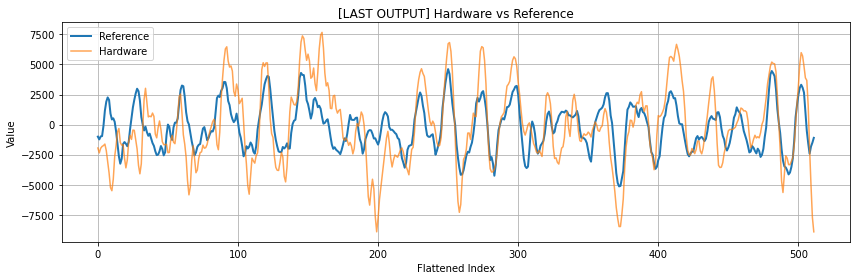

In [49]:
graph_flatten_compare(
        CONV_RESULTS["OUT"],
        FULL_LAYER_OUTPUTS["OUT"],
        title=f"[LAST OUTPUT] Hardware vs Reference"
    )

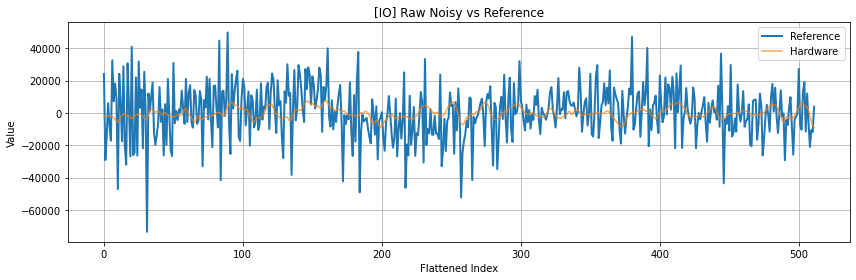

In [50]:
graph_flatten_compare(
        CONV_RESULTS["OUT"],
        CONV_IFMAPS["E1"],
        title=f"[IO] Raw Noisy vs Reference"
    )

In [51]:
compare_hardware_vs_reference(
        hardware=FULL_LAYER_OUTPUTS["OUT"],
        reference= CONV_RESULTS["OUT"],
        layer_name=f"LAYER {LAYER_NAME} Result Analysis",
        num_ch=FULL_LAYER_OUTPUTS[f"{LAYER_NAME}"].shape[0],
        rrmse_thresh=0.20,
        corr_thresh=0.90
    )

LAYER OUT Result Analysis — Hardware vs Reference Comparison
  Shape : (1, 512)
  RRMSE : 7.533878e-01  (WARN ✗)
  Corr  : 0.659729   (WARN ✗)

  --- Worst 5 by RRMSE ---
    ch         rrmse        corr
     0  7.533878e-01    0.659729

  --- Worst 5 by Corr ---
    ch         rrmse        corr
     0  7.533878e-01    0.659729


{'rrmse': 0.7533878167556066,
 'corr': 0.6597288294691828,
 'ch_rrmse': [0.7533878167556066],
 'ch_corr': [0.6597288294691828],
 'pass': False}

In [58]:
metrics = evaluation_metrics(FULL_LAYER_OUTPUTS["OUT"], CONV_RESULTS["OUT"])

print(f"{'Metric':<20} | {'Value':<15}")
print("-" * 38)
print(f"{'SNR (Linear Ratio)':<20} | {metrics['SNR_linear']:<15.4f}")
print(f"{'SNR (dB)':<20} | {metrics['SNR_db']:<15.4f}")
print(f"{'RMSE':<20} | {metrics['RMSE']:<15.6f}")
print(f"{'Correlation':<20} | {metrics['Correlation']:<15.6f}")

Metric               | Value          
--------------------------------------
SNR (Linear Ratio)   | 0.6467         
SNR (dB)             | -1.8932        
RMSE                 | 2423.755385    
Correlation          | 0.659729       
